<a href="https://colab.research.google.com/github/akriti404/Deep-Learning-Lab/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Training DeepNetNoBN (LR = 0.01) ---
Epoch 01 | Train Loss: 0.9577 | Test Accuracy: 82.50%
Epoch 02 | Train Loss: 0.3359 | Test Accuracy: 87.22%
Epoch 03 | Train Loss: 0.2353 | Test Accuracy: 90.00%
Epoch 04 | Train Loss: 0.2356 | Test Accuracy: 93.33%
Epoch 05 | Train Loss: 0.1723 | Test Accuracy: 93.06%
Epoch 06 | Train Loss: 0.1428 | Test Accuracy: 92.50%
Epoch 07 | Train Loss: 0.0978 | Test Accuracy: 95.56%
Epoch 08 | Train Loss: 0.1695 | Test Accuracy: 94.44%
Epoch 09 | Train Loss: 0.1015 | Test Accuracy: 96.67%
Epoch 10 | Train Loss: 0.0578 | Test Accuracy: 96.39%
Epoch 11 | Train Loss: 0.1450 | Test Accuracy: 95.00%
Epoch 12 | Train Loss: 0.1282 | Test Accuracy: 93.61%
Epoch 13 | Train Loss: 0.1488 | Test Accuracy: 95.56%
Epoch 14 | Train Loss: 0.1131 | Test Accuracy: 93.61%
Epoch 15 | Train Loss: 0.1699 | Test Accuracy: 90.83%
Epoch 16 | Train Loss: 0.1668 | Test Accuracy: 95.28%
Epoch 17 | Train Loss: 0.0971 | Test Accuracy: 97.50%
Epoch 18 | Train Loss: 0.0693 | Test Accu

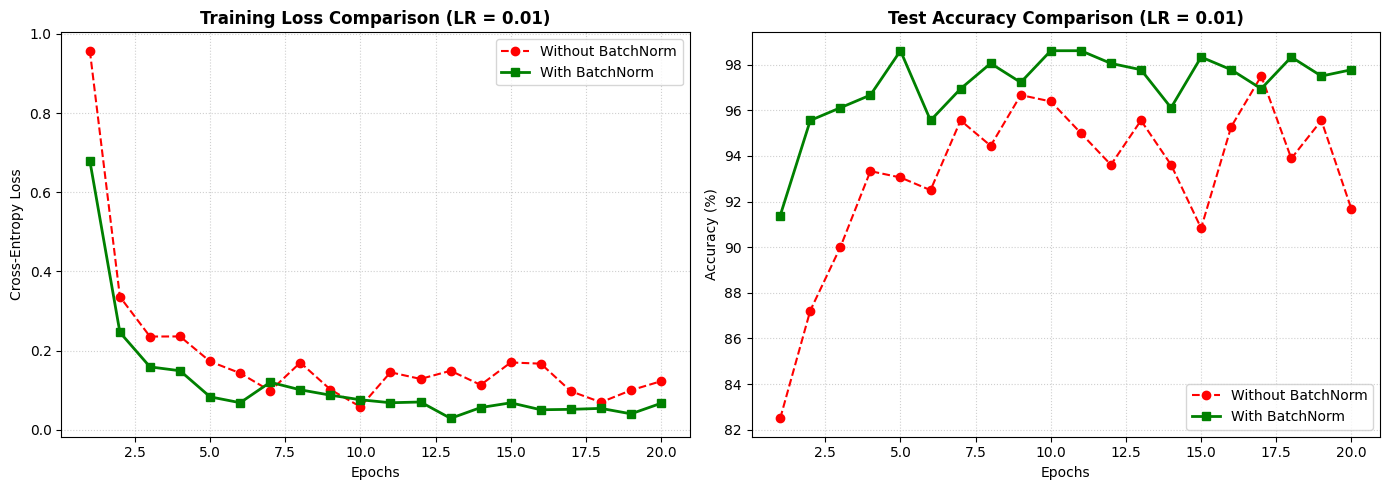

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X, y = load_digits(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=32,
    shuffle=False
)

class DeepNetNoBN(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class DeepNetWithBN(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def train(model, lr=0.01, epochs=20):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print(f"--- Training {model.__class__.__name__} (LR = {lr}) ---")

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for bx, by in test_loader:
                preds = model(bx).argmax(dim=1)
                correct += (preds == by).sum().item()
                total += by.size(0)

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)

        print(
            f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | "
            f"Test Accuracy: {accuracy:.2f}%"
        )

    return train_losses, test_accuracies


torch.manual_seed(42)
loss_no_bn, acc_no_bn = train(DeepNetNoBN(), lr=0.01)

torch.manual_seed(42)
loss_with_bn, acc_with_bn = train(DeepNetWithBN(), lr=0.01)

epochs_range = range(1, 21)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    loss_no_bn,
    label='Without BatchNorm',
    color='red',
    linestyle='--',
    marker='o'
)
plt.plot(
    epochs_range,
    loss_with_bn,
    label='With BatchNorm',
    color='green',
    linewidth=2,
    marker='s'
)
plt.title('Training Loss Comparison (LR = 0.01)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    acc_no_bn,
    label='Without BatchNorm',
    color='red',
    linestyle='--',
    marker='o'
)
plt.plot(
    epochs_range,
    acc_with_bn,
    label='With BatchNorm',
    color='green',
    linewidth=2,
    marker='s'
)
plt.title('Test Accuracy Comparison (LR = 0.01)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()